## 1.0) Setup

In [3]:
import torch
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
from torchvision.io import decode_image

In [4]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


## 2.0) Dataset

In [5]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

validation_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

print('Training:',len(training_data))
print('Validation + Testing:', len(validation_data))

100%|██████████| 9.91M/9.91M [00:00<00:00, 13.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 464kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.9MB/s]

Training: 60000
Validation + Testing: 10000


## 2.1) Validation-Test split

In [6]:
from torch.utils.data import random_split

split_generator = torch.Generator().manual_seed(31)

validation_data, testing_data = random_split(validation_data, [5000,5000], generator=split_generator)

print('Validation:', len(validation_data))
print('Testing:', len(testing_data))

Validation: 5000
Testing: 5000


## 2.2) Dataset overview

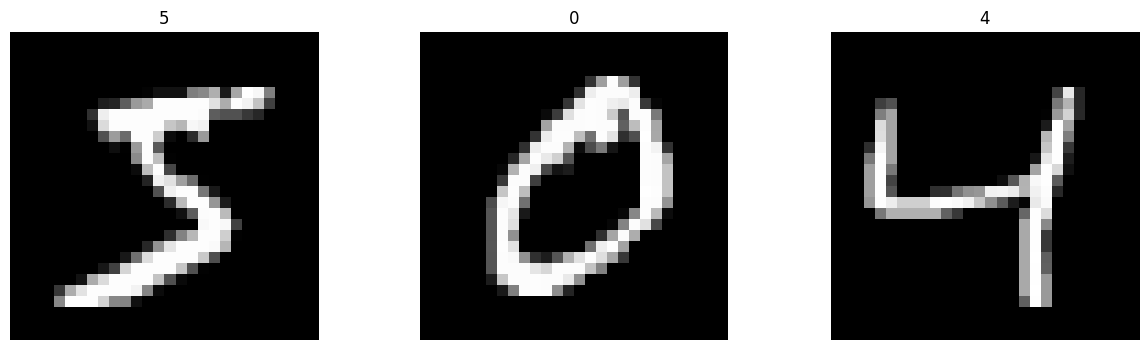

Tamanho da imagem: torch.Size([1, 28, 28])


In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i in range(3):
  img, label = training_data[i]
  axes[i].imshow(img.permute(1, 2, 0), cmap='gray')
  axes[i].axis("off")
  axes[i].set_title(label)

plt.show()

print('Tamanho da imagem:',img.shape)

## 2.3) Dataloaders

In [7]:
training_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=64, shuffle=True)
testing_dataloader = DataLoader(testing_data, batch_size=64, shuffle=True)

## 3.0) Architecture

In [8]:
import torch.nn.functional as F

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Define model
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        # 1st convolutional layer
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=8, kernel_size=3, padding=1)
        # Max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # 2nd convolutional layer
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
        # Flatten layer
        self.flatten = nn.Flatten()
        # Fully connected layer
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(16*7*7, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using cuda device
NeuralNetwork(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


## 3.1) Training

In [ ]:
import torch.optim as optim

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
best_loss = float('inf')
stop = 0
for epoch in range(50):
  model.train()
  print(f'Época {epoch+1}/50...')
  for i, (X, y) in enumerate(training_dataloader):
      if i % 100 == 0:
        print(f'  Batch {i+1}/{len(training_dataloader)+1}...')
      X, y = X.to(device), y.to(device)

      # Compute prediction error
      pred = model(X)
      loss = loss_fn(pred, y)

      # Backpropagation
      loss.backward()
      optimizer.step()
      optimizer.zero_grad()

  model.eval()
  val_loss = 0
  acc = 0
  with torch.no_grad():
    print(f'  Validação...')
    for X, y in validation_dataloader:
      X, y = X.to(device), y.to(device)

      pred = model(X)
      loss = loss_fn(pred, y)

      val_loss += loss.item()
      acc += (pred.argmax(1) == y).type(torch.float).sum().item()

    val_loss = val_loss / len(validation_dataloader)
    acc = acc / len(validation_data)
    print(f'  Acurácia: {(acc*100):.2f}, Validation loss: {val_loss}')
    if val_loss < best_loss:
      best_loss = val_loss
      stop = 0
      torch.save(model.state_dict(), '/content/drive/MyDrive/pesos_mnist.pth')
    else:
      stop += 1
      if stop == 5:
        break

Época 1/50...
  Batch 1/939...
  Batch 101/939...
  Batch 201/939...
  Batch 301/939...
  Batch 401/939...
  Batch 501/939...
  Batch 601/939...
  Batch 701/939...
  Batch 801/939...
  Batch 901/939...
  Validação...
  Acurácia: 98.30, Validation loss: 0.05039239396588712
Época 2/50...
  Batch 1/939...
  Batch 101/939...
  Batch 201/939...
  Batch 301/939...
  Batch 401/939...
  Batch 501/939...
  Batch 601/939...
  Batch 701/939...
  Batch 801/939...
  Batch 901/939...
  Validação...
  Acurácia: 98.24, Validation loss: 0.045092280290997294
Época 3/50...
  Batch 1/939...
  Batch 101/939...
  Batch 201/939...
  Batch 301/939...
  Batch 401/939...
  Batch 501/939...
  Batch 601/939...
  Batch 701/939...
  Batch 801/939...
  Batch 901/939...
  Validação...
  Acurácia: 98.52, Validation loss: 0.04658769552678436
Época 4/50...
  Batch 1/939...
  Batch 101/939...
  Batch 201/939...
  Batch 301/939...
  Batch 401/939...
  Batch 501/939...
  Batch 601/939...
  Batch 701/939...
  Batch 801/939.

## 4.0) Evaluation on Test set

In [ ]:
model.eval()
with torch.no_grad():
  acc = 0
  for X,y in testing_dataloader:
    X, y = X.to(device), y.to(device)

    pred = model(X)
    loss = loss_fn(pred, y)
    acc += (pred.argmax(1) == y).type(torch.float).sum().item()

  acc = acc / len(testing_data)
  print(f'Acurácia: {(acc*100):.2f}')

Acurácia: 99.16


## 5.0) tsne-cuda download (https://github.com/CannyLab/tsne-cuda)

In [1]:
!pip install -q condacolab
import condacolab; condacolab.install()   # reinicia o kernel sozinho

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:08
🔁 Restarting kernel...


In [1]:
!conda install -q -y -c conda-forge tsnecuda

Retrieving notices: ...working... done
Channels:
 - conda-forge
Platform: linux-64
Solving environment: ...working... done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - tsnecuda


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _x86_64-microarch-level-4  | 3_skylake_avx512          10 KB  conda-forge
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    certifi-2026.7.22          |     pyhd8ed1ab_0         134 KB  conda-forge
    conda-26.3.2               |  py312h7900ff3_1         1.2 MB  conda-forge
    cuda-cudart-12.9.79        |       h5888daf_0          23 KB  conda-forge
    cuda-cudart_linux-64-12.9.79|       h3f2d84a_0         193 KB  conda-forge
    cuda-nvrtc-12.9.86         |       hecca717_1        64.1 MB  conda-forge
    cuda-version-12.9          |       h4f385c5_3          21 KB  conda-forge
    libbl

In [2]:
!python -c "import tsnecuda; tsnecuda.test()"

Initializing cuda handles... done.
KNN Computation... done.
Computing Pij matrix... 
done.
Initializing low dim points... done.
Initializing CUDA memory... done.
[Step 0] Avg. Gradient Norm: 0.00314612
[Step 10] Avg. Gradient Norm: 0.000203822
[Step 20] Avg. Gradient Norm: 1.17559e-05
[Step 30] Avg. Gradient Norm: 6.14931e-07
[Step 40] Avg. Gradient Norm: 3.41341e-08
[Step 50] Avg. Gradient Norm: 1.81923e-09
[Step 60] Avg. Gradient Norm: 8.97721e-10
[Step 70] Avg. Gradient Norm: 2.49206e-09
[Step 80] Avg. Gradient Norm: 3.53948e-10
[Step 90] Avg. Gradient Norm: 4.07195e-09
[Step 100] Avg. Gradient Norm: 3.32931e-09
[Step 110] Avg. Gradient Norm: 1.3805e-08
[Step 120] Avg. Gradient Norm: 4.15707e-09
[Step 130] Avg. Gradient Norm: 3.90884e-09
[Step 140] Avg. Gradient Norm: 6.71075e-09
[Step 150] Avg. Gradient Norm: 2.61292e-09
[Step 160] Avg. Gradient Norm: 2.49106e-09
[Step 170] Avg. Gradient Norm: 2.74709e-09
[Step 180] Avg. Gradient Norm: 1.21758e-08
[Step 190] Avg. Gradient Norm: 2.7

## 5.1) T-SNE on MNIST

### 5.1.1) Loading model & cutting last layer

In [9]:
model_embedding = NeuralNetwork().to(device)
weights = torch.load("/content/drive/MyDrive/pesos_mnist.pth")
model_embedding.load_state_dict(weights)
model_embedding.linear_relu_stack = model_embedding.linear_relu_stack[:-1]
print(model_embedding)

NeuralNetwork(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
  )
)


### 5.1.2) Stacking X with all training_data

In [10]:
Xs = []

for x, y in training_data:
    Xs.append(x)

X = torch.stack(Xs)

print(X.shape)

torch.Size([60000, 1, 28, 28])


### 5.1.3) X embedding

In [11]:
model_embedding.eval()
with torch.no_grad():
  X = X.to(device)
  X_embedding = model_embedding(X)
print(X_embedding.shape)
print(X_embedding)

torch.Size([60000, 512])
tensor([[1.5593, 0.0000, 0.0000,  ..., 0.0000, 2.4215, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 1.3042, 0.0000, 0.0000],
        [0.0000, 0.8948, 0.9767,  ..., 0.0000, 1.3423, 0.0000],
        ...,
        [0.7615, 0.0000, 0.0000,  ..., 0.0000, 1.8318, 0.0000],
        [0.0000, 0.0000, 0.2767,  ..., 0.5248, 0.1485, 0.0000],
        [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000]],
       device='cuda:0')


### 5.1.4) tsne-cuda

In [21]:
from tsnecuda import TSNE
import numpy as np

X_tsne = TSNE(n_components=2, perplexity=30, learning_rate=500).fit_transform(X_embedding.detach().cpu().numpy().astype(np.float32))

In [22]:
print(X_tsne.shape)
print(X_tsne)

(60000, 2)
[[ -9.72993   -20.302597 ]
 [-24.510477  -24.48244  ]
 [ 20.61612    -9.507006 ]
 ...
 [-10.974552  -33.71775  ]
 [  5.2556562 -21.208641 ]
 [ 25.73021   -42.598263 ]]


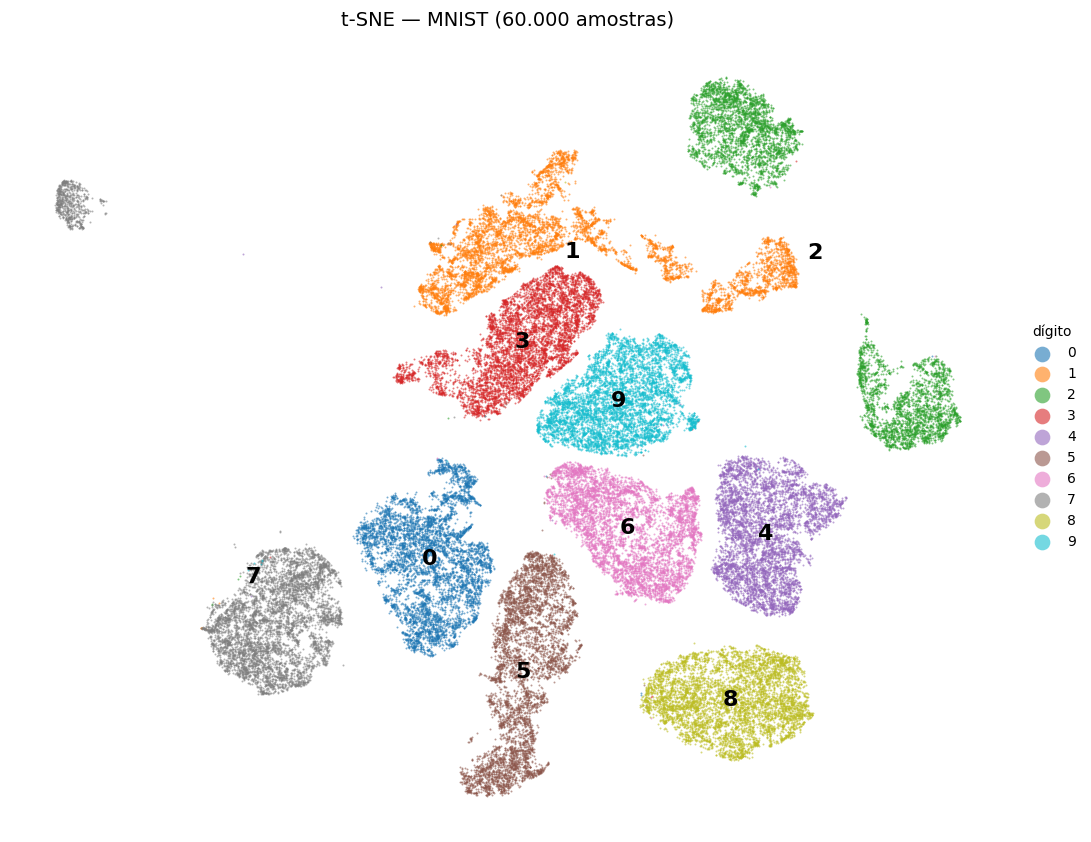

In [23]:
import matplotlib.pyplot as plt

# ---- rótulos -------------------------------------------------------------
# training_data.targets já está na mesma ordem de indexação de training_data[i],
# então evita 60k chamadas a __getitem__ (que aplicariam o transform à toa).
if hasattr(training_data, 'targets'):
    y = np.asarray(training_data.targets)
else:
    y = np.array([training_data[i][1] for i in range(len(training_data))])

assert X_tsne.shape[0] == y.shape[0], (X_tsne.shape, y.shape)

# ---- plot ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 10))
cmap = plt.get_cmap('tab10')

for d in range(10):
    m = y == d
    ax.scatter(X_tsne[m, 0], X_tsne[m, 1],
               s=2, color=cmap(d), label=str(d), alpha=0.6, linewidths=0)

    # centróide de cada dígito, como referência de leitura
    cx, cy = X_tsne[m, 0].mean(), X_tsne[m, 1].mean()
    ax.text(cx, cy, str(d), fontsize=16, fontweight='bold',
            ha='center', va='center', color='black',
            path_effects=[])

ax.set_aspect('equal')
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)

ax.set_title('t-SNE — MNIST (60.000 amostras)', fontsize=14, pad=12)
ax.legend(markerscale=8, title='dígito', loc='center left',
          bbox_to_anchor=(1.01, 0.5), frameon=False)

plt.tight_layout()
fig.savefig('tsne_mnist.png', dpi=150, bbox_inches='tight')
plt.show()